In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.metrics import precision_recall_curve, f1_score




In [2]:
df = pd.read_csv('../data/processed/pns_2019_transformed.csv')
df.shape

(87657, 70)

In [3]:
df = df.dropna()
df.shape

(74304, 70)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 74304 entries, 0 to 87655
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   situacao_domicilio      74304 non-null  int64  
 1   acesso_internet         74304 non-null  int64  
 2   plano_saude             74304 non-null  float64
 3   hipertensao             74304 non-null  float64
 4   diabetes                74304 non-null  float64
 5   doenca_coracao          74304 non-null  float64
 6   infarto                 74304 non-null  float64
 7   angina                  74304 non-null  float64
 8   insuficiencia_cardiaca  74304 non-null  float64
 9   arritmia                74304 non-null  float64
 10  avc                     74304 non-null  float64
 11  asma                    74304 non-null  float64
 12  artrite                 74304 non-null  float64
 13  dort                    74304 non-null  float64
 14  depressao               74304 non-null  float64
 15  d

In [435]:
# Contagem absoluta
contagem = df["doenca_cronica"].value_counts(dropna=False)

# Proporção
proporcao = (
    df["doenca_cronica"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

resumo = pd.DataFrame({
    "qtd": contagem,
    "percentual_%": proporcao
})

resumo

,qtd,percentual_%
doenca_cronica,,
0,39647,53.36
1,34657,46.64


In [436]:
df["doenca_cronica"].value_counts(normalize=True)

doenca_cronica
0    0.533578
1    0.466422
Name: proportion, dtype: float64

### Testar Interações entre Variaveis


In [437]:
# interação entre escolaridade e atividade física
df["esc_x_atividade"] = df["escolaridade_ord"] * df["atividade_ativo"] 

# interação entre escolaridade e tabagismo
df["esc_x_tabagismo"] = df["escolaridade_ord"] * df["tabagismo_ativo"]

# interação entre escolaridade e alcoolismo
df["esc_x_alcool"] = df["escolaridade_ord"] * df["alcool_ativo"]

# interação entre renda e imc
df["renda_x_imc"] = df["renda_per_capita_log"] * df["imc"]

# interação entre infraestrutura e atividade física
df["infra_x_atividade"] = df["infra_agua"] * df["atividade_ativo"]

# interação entre sexo e comportamento
df["sexo_x_atividade"] = df["sexo_feminino"] * df["atividade_ativo"]
df["sexo_x_imc"] = df["sexo_feminino"] * df["imc"]

# interação entre atividade física e imc, tabagismo e imc
df["atividade_x_imc"] = df["atividade_ativo"] * df["imc"]
df["tabagismo_x_imc"] = df["tabagismo_ativo"] * df["imc"]

In [438]:
# verifica valores de situacao_domicilio
# hipertensao               27.052396
# depressao                  9.329592
# diabetes                   8.352152
df["hipertensao"].value_counts()

hipertensao
0.0    52146
1.0    22158
Name: count, dtype: int64

In [439]:
df["esc_x_idade"] = df["escolaridade_ord"] * df["idade_c"] 
df["renda_x_idade"] = df["renda_per_capita_log"] * df["idade_c"] 
df["atividade_x_idade"] = df["atividade_ativo"] * df["idade_c"] 
df["tabagismo_x_idade"] = df["tabagismo_status"] * df["idade_c"] 
df["alcool_x_idade"] = df["alcool_ativo"] * df["idade_c"] 
df["imc_x_idade"] = df["imc"] * df["idade_c"]  
df["plano_x_idade"] = df["plano_saude"] * df["idade_c"]  
df["situacao_x_idade"] = df["situacao_domicilio"] * df["idade_c"]  
df["sexo_x_idade"] = df["sexo_feminino"] * df["idade_c"] 

features_base_bio = [
    "atividade_ativo",
    "tabagismo_ativo",
    "alcool_ativo",
    "imc",
    "sexo_feminino",
    "idade_c"
]

features_x_idade_bio = [
    "atividade_x_idade",
    "tabagismo_x_idade",
    "alcool_x_idade",
    "sexo_x_idade",
]

features_base_dss = [
    "escolaridade_ord",
    "renda_per_capita_log",
    "atividade_ativo",
    "tabagismo_ativo",
    "alcool_ativo",
    "imc",
    "sexo_feminino",
    "plano_saude",
    "situacao_domicilio",
    "idade_c"
]

features_x_idade_dss = [
    "esc_x_idade",
    "renda_x_idade",
    "atividade_x_idade",
    "tabagismo_x_idade",
    "alcool_x_idade",
    "plano_x_idade",
    "situacao_x_idade",
    "sexo_x_idade",
]




features_final_bio = features_base_bio + features_x_idade_bio
features_final_dss = features_base_dss + features_x_idade_dss

## Criar matriz X

In [440]:
# Modelo 1: DSS
X_bio = df[features_final_bio]
X_dss = df[features_final_dss]
 

## Definir variavel alvo

In [441]:
y = df["doenca_cronica"]

In [442]:
# Modelo 1
X_bio_train, X_bio_test, y_bio_train, y_bio_test = train_test_split(
    X_bio, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_bio_resampled, y_bio_resampled = smote.fit_resample(X_bio_train, y_bio_train)
 
# Modelo 1
X_dss_train, X_dss_test, y_dss_train, y_dss_test = train_test_split(
    X_dss, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_bio_resampled, y_bio_resampled = smote.fit_resample(X_bio_train, y_bio_train)
X_dss_resampled, y_dss_resampled = smote.fit_resample(X_dss_train, y_dss_train)
 

## Padronização
Lasso necessita de escala padronizada

In [443]:
scaler = StandardScaler()

# Modelo 1
X_bio_train_scaled = scaler.fit_transform(X_bio_resampled)
X_bio_test_scaled = scaler.transform(X_bio_test)

# Modelo 2: DSS
X_dss_train_scaled = scaler.fit_transform(X_dss_resampled)
X_dss_test_scaled = scaler.transform(X_dss_test)


## Treinar Modelo LASSO L1
usar cross validation para escolher λ automaticamente



In [444]:
modelo_bio = LogisticRegressionCV(

    penalty="l1",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

modelo_dss = LogisticRegressionCV(

    penalty="l1",
    solver="saga",
    cv=5,
    scoring="roc_auc",
    max_iter=5000,
    n_jobs=-1,
    random_state=42
    
)

modelo_bio.fit(X_bio_train_scaled, y_bio_resampled)
modelo_dss.fit(X_dss_train_scaled, y_dss_resampled)



d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
d:\Workspace\TCCII\tcc_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass settin

Melhor threshold pelo F1: 0.40
              precision    recall  f1-score   support

           0       0.78      0.56      0.65      7930
           1       0.62      0.81      0.70      6931

    accuracy                           0.68     14861
   macro avg       0.70      0.69      0.68     14861
weighted avg       0.70      0.68      0.67     14861



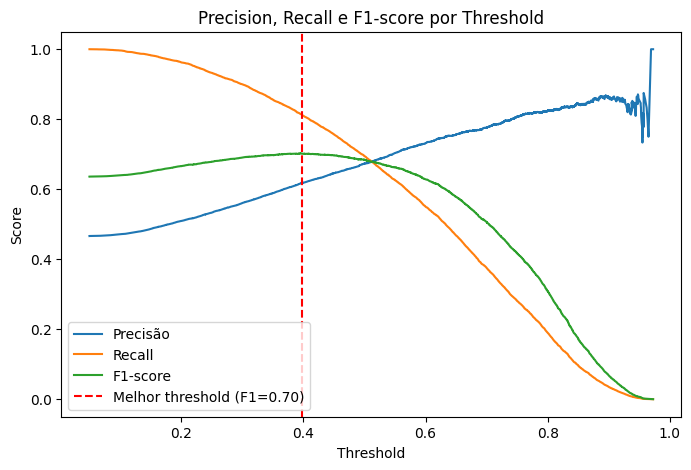

In [445]:

y_bio_prob = modelo_bio.predict_proba(X_bio_test_scaled)[:, 1]

precisions_bio, recalls_bio, thresholds_bio = precision_recall_curve(y_bio_test, y_bio_prob)
f1_bio_scores = 2 * (precisions_bio * recalls_bio) / (precisions_bio + recalls_bio + 1e-8)

best_idx_bio = f1_bio_scores[:-1].argmax()
best_threshold_bio = thresholds_bio[best_idx_bio]
print(f"Melhor threshold pelo F1: {best_threshold_bio:.2f}")
print(classification_report(y_bio_test, (y_bio_prob >= best_threshold_bio).astype(int)))

plt.figure(figsize=(8,5))
plt.plot(thresholds_bio, precisions_bio[:-1], label='Precisão')
plt.plot(thresholds_bio, recalls_bio[:-1], label='Recall')
plt.plot(thresholds_bio, f1_bio_scores[:-1], label='F1-score')
plt.axvline(best_threshold_bio, color='red', linestyle='--', label=f'Melhor threshold (F1={f1_bio_scores[best_idx_bio]:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1-score por Threshold')
plt.legend()
plt.show()

Melhor threshold pelo F1: 0.40
              precision    recall  f1-score   support

           0       0.77      0.57      0.65      7930
           1       0.62      0.81      0.70      6931

    accuracy                           0.68     14861
   macro avg       0.70      0.69      0.68     14861
weighted avg       0.70      0.68      0.68     14861



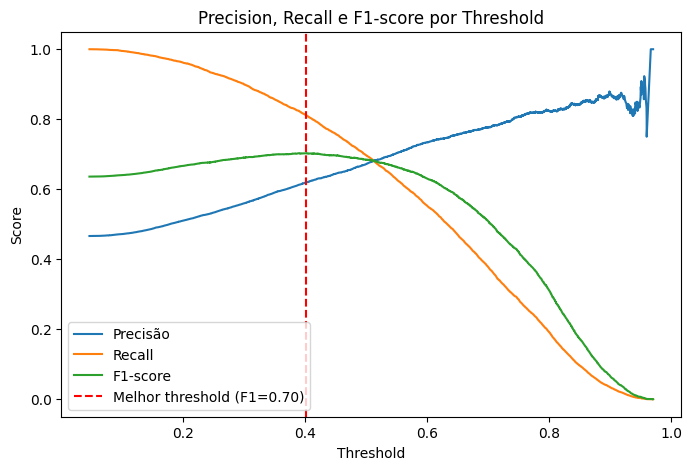

In [446]:

y_prob_dss = modelo_dss.predict_proba(X_dss_test_scaled)[:, 1]

precisions_dss, recalls_dss, thresholds_dss = precision_recall_curve(y_dss_test, y_prob_dss)
f1_dss_scores = 2 * (precisions_dss * recalls_dss) / (precisions_dss + recalls_dss + 1e-8)

best_idx_dss = f1_dss_scores[:-1].argmax()
best_threshold_dss = thresholds_dss[best_idx_dss]
print(f"Melhor threshold pelo F1: {best_threshold_dss:.2f}")
print(classification_report(y_dss_test, (y_prob_dss >= best_threshold_dss).astype(int)))

plt.figure(figsize=(8,5))
plt.plot(thresholds_dss, precisions_dss[:-1], label='Precisão')
plt.plot(thresholds_dss, recalls_dss[:-1], label='Recall')
plt.plot(thresholds_dss, f1_dss_scores[:-1], label='F1-score')
plt.axvline(best_threshold_dss, color='red', linestyle='--', label=f'Melhor threshold (F1={f1_dss_scores[best_idx_dss]:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall e F1-score por Threshold')
plt.legend()
plt.show()

In [447]:
# Usar o melhor threshold encontrado para predições e métricas finais
# y_proba já foi calculado anteriormente

y_pred_otimo = (y_bio_prob >= best_threshold_bio).astype(int)

print("Relatório de classificação com threshold ótimo:")
print(classification_report(y_bio_test, y_pred_otimo))
print("Matriz de confusão:")
print(confusion_matrix(y_bio_test, y_pred_otimo))

Relatório de classificação com threshold ótimo:
              precision    recall  f1-score   support

           0       0.78      0.56      0.65      7930
           1       0.62      0.81      0.70      6931

    accuracy                           0.68     14861
   macro avg       0.70      0.69      0.68     14861
weighted avg       0.70      0.68      0.67     14861

Matriz de confusão:
[[4440 3490]
 [1289 5642]]


In [448]:
# Usar o melhor threshold encontrado para predições e métricas finais
# y_proba já foi calculado anteriormente

y_dss_otimo = (y_prob_dss >= best_threshold_dss).astype(int)

print("Relatório de classificação com threshold ótimo:")
print(classification_report(y_dss_test, y_dss_otimo))
print("Matriz de confusão:")
print(confusion_matrix(y_dss_test, y_dss_otimo))

Relatório de classificação com threshold ótimo:
              precision    recall  f1-score   support

           0       0.77      0.57      0.65      7930
           1       0.62      0.81      0.70      6931

    accuracy                           0.68     14861
   macro avg       0.70      0.69      0.68     14861
weighted avg       0.70      0.68      0.68     14861

Matriz de confusão:
[[4481 3449]
 [1305 5626]]


## Avaliação 

### Predição

In [449]:
y_bio_pred = modelo_bio.predict(X_bio_test_scaled)
y_prob = modelo_bio.predict_proba(X_bio_test_scaled)[:,1]

In [450]:
y_dss_pred = modelo_dss.predict(X_dss_test_scaled)
y_dss_prob = modelo_dss.predict_proba(X_dss_test_scaled)[:,1]

### Métricas

In [451]:
print("MODELO BIOMEDICO")
print("AUC:", roc_auc_score(y_bio_test, y_bio_prob))
print("Accuracy:", accuracy_score(y_bio_test, y_bio_pred))
print(classification_report(y_bio_test, y_bio_pred))

MODELO BIOMEDICO
AUC: 0.7624890858058073
Accuracy: 0.7005585088486643
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      7930
           1       0.67      0.69      0.68      6931

    accuracy                           0.70     14861
   macro avg       0.70      0.70      0.70     14861
weighted avg       0.70      0.70      0.70     14861



In [452]:
print("MODELO DSS")
print("AUC:", roc_auc_score(y_dss_test, y_dss_prob))
print("Accuracy:", accuracy_score(y_dss_test, y_dss_pred))
print(classification_report(y_dss_test, y_dss_pred))

MODELO DSS
AUC: 0.7629865401763338
Accuracy: 0.6998856066213579
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      7930
           1       0.67      0.70      0.68      6931

    accuracy                           0.70     14861
   macro avg       0.70      0.70      0.70     14861
weighted avg       0.70      0.70      0.70     14861



## Matriz de Confusão

In [453]:
print("Matriz de confusão - Modelo Biomédico:")
confusion_matrix(y_bio_test, y_bio_pred)



Matriz de confusão - Modelo Biomédico:


array([[5595, 2335],
       [2115, 4816]])

In [454]:
print("Matriz de confusão - Modelo DSS:")
confusion_matrix(y_dss_test, y_dss_pred)



Matriz de confusão - Modelo DSS:


array([[5571, 2359],
       [2101, 4830]])

## Extrair coeficientes

In [455]:
coef_bio = pd.Series(
    modelo_bio.coef_[0],
    index=features_final_bio
)

coef_dss = pd.Series(
    modelo_dss.coef_[0],
    index=features_final_dss
)
 
 


## Variaveis selecionadas pelo LASSO

In [456]:
print("Coeficientes do Modelo Biomédico:")
coef_selecionados_bio = coef_bio[coef_bio != 0]

coef_selecionados_bio.sort_values()


Coeficientes do Modelo Biomédico:


tabagismo_x_idade   -0.065521
alcool_ativo        -0.064185
atividade_ativo     -0.010882
sexo_x_idade        -0.010724
alcool_x_idade      -0.010109
atividade_x_idade    0.008471
tabagismo_ativo      0.041067
sexo_feminino        0.292135
imc                  0.354749
idade_c              1.010108
dtype: float64

In [457]:
print("Coeficientes do Modelo DSS:")
coef_selecionados_dss = coef_dss[coef_dss != 0]

coef_selecionados_dss.sort_values()


Coeficientes do Modelo DSS:


renda_x_idade          -0.112712
alcool_ativo           -0.065919
escolaridade_ord       -0.062873
tabagismo_x_idade      -0.061456
sexo_x_idade           -0.020772
plano_x_idade          -0.016266
alcool_x_idade         -0.012713
atividade_ativo        -0.009572
situacao_x_idade       -0.002148
atividade_x_idade       0.003373
renda_per_capita_log    0.023022
situacao_domicilio      0.025515
tabagismo_ativo         0.044544
esc_x_idade             0.055448
plano_saude             0.069168
sexo_feminino           0.291079
imc                     0.352675
idade_c                 1.064658
dtype: float64

## Calcular ODDS Ratio
Odds Ratio = exp(coeficiente)

In [458]:
print("Odds Ratios do Modelo Biomédico:")
odds_ratio_bio = np.exp(coef_bio)

odds_ratio_bio.sort_values()

Odds Ratios do Modelo Biomédico:


tabagismo_x_idade    0.936580
alcool_ativo         0.937832
atividade_ativo      0.989177
sexo_x_idade         0.989333
alcool_x_idade       0.989942
atividade_x_idade    1.008507
tabagismo_ativo      1.041922
sexo_feminino        1.339284
imc                  1.425823
idade_c              2.745898
dtype: float64

In [459]:
print("Odds Ratios do Modelo DSS:")
odds_ratio_dss = np.exp(coef_dss)

odds_ratio_dss.sort_values()

Odds Ratios do Modelo DSS:


renda_x_idade           0.893408
alcool_ativo            0.936206
escolaridade_ord        0.939062
tabagismo_x_idade       0.940394
sexo_x_idade            0.979442
plano_x_idade           0.983866
alcool_x_idade          0.987367
atividade_ativo         0.990474
situacao_x_idade        0.997854
atividade_x_idade       1.003379
renda_per_capita_log    1.023289
situacao_domicilio      1.025843
tabagismo_ativo         1.045551
esc_x_idade             1.057014
plano_saude             1.071616
sexo_feminino           1.337870
imc                     1.422869
idade_c                 2.899847
dtype: float64

## Tabelas Finais

In [460]:
resultado_bio = pd.DataFrame({

    "coeficiente": coef_selecionados_bio,
    "odds_ratio": np.exp(coef_selecionados_bio)

}).sort_values("odds_ratio")

print("Resultado do Modelo Biomédico:")
resultado_bio


Resultado do Modelo Biomédico:


,coeficiente,odds_ratio
tabagismo_x_idade,-0.065521,0.936580
alcool_ativo,-0.064185,0.937832
atividade_ativo,-0.010882,0.989177
sexo_x_idade,-0.010724,0.989333
alcool_x_idade,-0.010109,0.989942
atividade_x_idade,0.008471,1.008507
tabagismo_ativo,0.041067,1.041922
sexo_feminino,0.292135,1.339284
imc,0.354749,1.425823
idade_c,1.010108,2.745898


In [461]:
resultado_dss = pd.DataFrame({

    "coeficiente": coef_selecionados_dss,
    "odds_ratio": np.exp(coef_selecionados_dss)

}).sort_values("odds_ratio")

print("Resultado do Modelo DSS:")
resultado_dss


Resultado do Modelo DSS:


,coeficiente,odds_ratio
renda_x_idade,-0.112712,0.893408
alcool_ativo,-0.065919,0.936206
escolaridade_ord,-0.062873,0.939062
tabagismo_x_idade,-0.061456,0.940394
sexo_x_idade,-0.020772,0.979442
plano_x_idade,-0.016266,0.983866
alcool_x_idade,-0.012713,0.987367
atividade_ativo,-0.009572,0.990474
situacao_x_idade,-0.002148,0.997854
atividade_x_idade,0.003373,1.003379
